# Task 1 & 2: Brent Oil Price - Data Preparation and Exploratory Data Analysis

**Birhan Energies - Change Point Analysis Project**

This notebook covers:
1. Data loading and preprocessing
2. Time series visualization
3. Log returns calculation
4. Stationarity testing (ADF)
5. Volatility pattern analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline


## 1. Load and Prepare Data

In [2]:
df = pd.read_csv('../data/BrentOilPrices.csv')
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df.head()


Shape: (9011, 2)
Date range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [3]:
df.describe()


,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958720,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


## 2. Load Events Data

In [4]:
events = pd.read_csv('../data/events.csv')
events['Date'] = pd.to_datetime(events['Date'])
print(f"Number of events: {len(events)}")
events


Number of events: 15


,Date,Event,Category,Description
0,1990-08-02,Iraq invades Kuwait,Conflict,Gulf War begins; triggers sharp oil price spik...
1,2001-09-11,September 11 attacks,Geopolitical,Terrorist attacks in the US cause short-term m...
2,2003-03-20,US invasion of Iraq,Conflict,Start of the Iraq War disrupts regional oil su...
3,2008-07-11,Oil price peaks near $147/barrel,Market Event,Record high Brent price driven by demand growt...
4,2008-09-15,Lehman Brothers collapse,Economic,Start of the Global Financial Crisis; oil dema...
5,2010-12-18,Arab Spring begins,Geopolitical,Political unrest across MENA region starting i...
6,2011-02-15,Libyan Civil War begins,Conflict,Loss of Libyan oil production tightens global ...
7,2014-11-27,OPEC maintains production despite price plunge,OPEC Policy,"OPEC declines to cut output amid oversupply, a..."
8,2016-01-16,Iran sanctions lifted (JCPOA implementation),Sanctions,"Iran re-enters global oil markets, adding to s..."
9,2016-11-30,OPEC+ agreement to cut production,OPEC Policy,OPEC and allies agree to coordinated output cu...


## 3. Raw Price Series

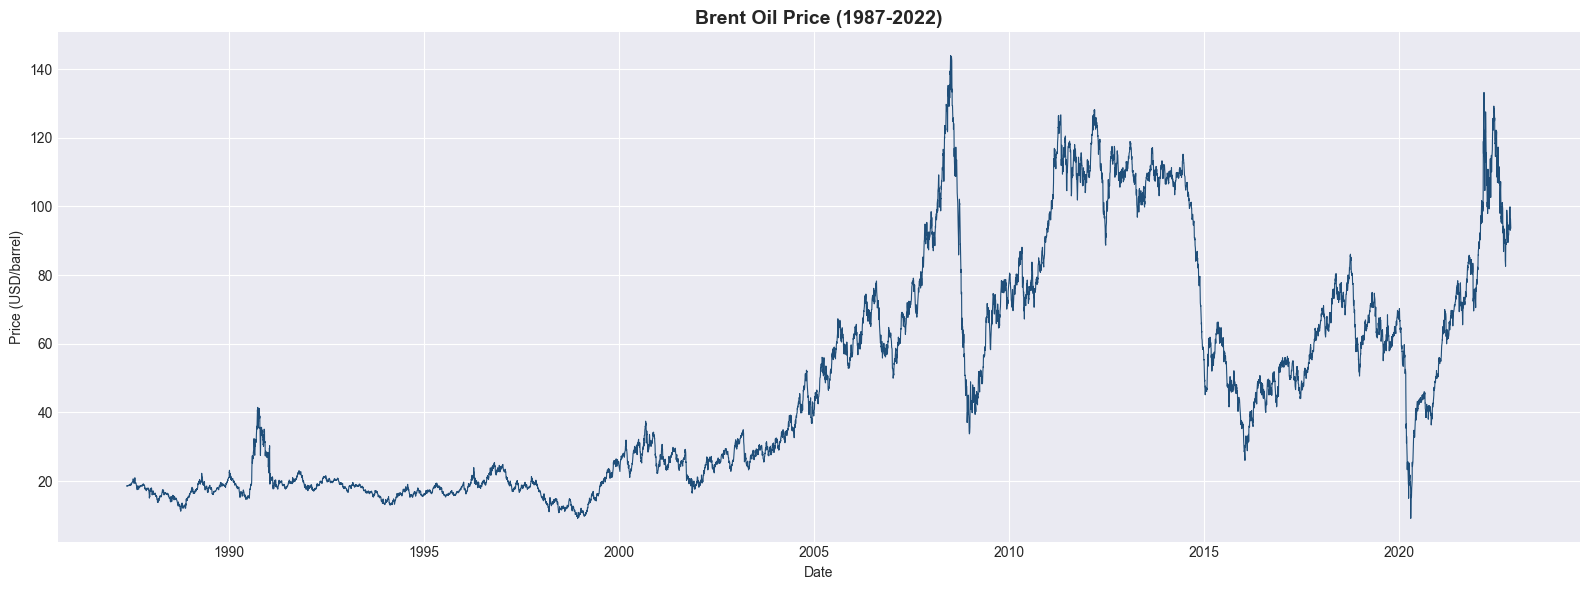

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Price'], linewidth=0.8, color='#1f4e79')
ax.set_title('Brent Oil Price (1987-2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD/barrel)')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../data/raw_price_series.png', dpi=150)
plt.show()


**Observations to note here:** look for long-run trend direction, the major spikes/crashes (1990, 2008, 2014-16, 2020, 2022), and whether volatility looks constant or clustered over time. Fill in your written observations after running this cell.

## 4. Log Returns

In [6]:
df['LogPrice'] = np.log(df['Price'])
df['LogReturn'] = df['LogPrice'].diff()
df_returns = df.dropna(subset=['LogReturn']).reset_index(drop=True)

df_returns[['Date', 'Price', 'LogReturn']].head()


,Date,Price,LogReturn
0,1987-05-21,18.45,-0.009709
1,1987-05-22,18.55,0.005405
2,1987-05-25,18.60,0.002692
3,1987-05-26,18.63,0.001612
4,1987-05-27,18.60,-0.001612


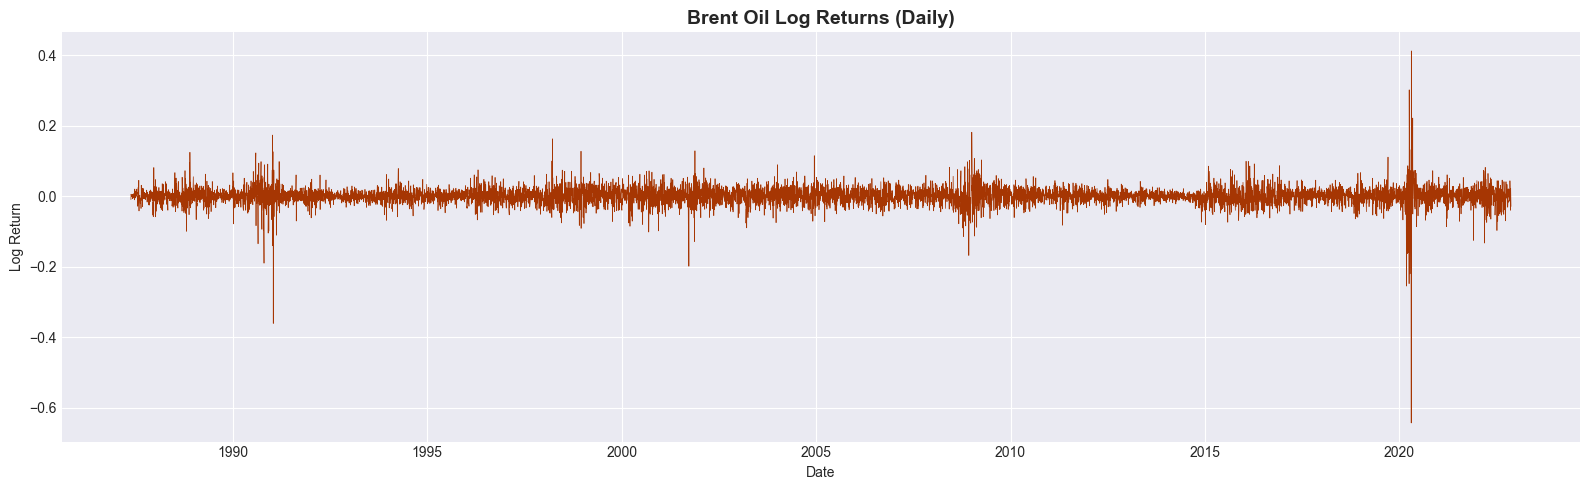

In [7]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_returns['Date'], df_returns['LogReturn'], linewidth=0.5, color='#a63603')
ax.set_title('Brent Oil Log Returns (Daily)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../data/log_returns.png', dpi=150)
plt.show()


**Volatility clustering:** note the visibly wider bands of log returns around 2008-09, 2014-16, and 2020 — periods of high volatility clustered together, a classic sign of GARCH-type behavior in financial time series.

## 5. Stationarity Testing (Augmented Dickey-Fuller)

In [8]:
def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    if result[1] < 0.05:
        print(">> Stationary (reject H0 of unit root)")
    else:
        print(">> Non-stationary (fail to reject H0 of unit root)")
    print()

adf_report(df['Price'], 'Raw Price')
adf_report(df_returns['LogReturn'], 'Log Returns')


--- ADF Test: Raw Price ---
ADF Statistic: -1.9939
p-value: 0.2893
Critical Values: {'1%': np.float64(-3.4310783342658615), '5%': np.float64(-2.861861876398633), '10%': np.float64(-2.566941329781918)}
>> Non-stationary (fail to reject H0 of unit root)



--- ADF Test: Log Returns ---
ADF Statistic: -16.4271
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.4310783342658615), '5%': np.float64(-2.861861876398633), '10%': np.float64(-2.566941329781918)}
>> Stationary (reject H0 of unit root)



**Expected result:** the raw price series is typically non-stationary (has a unit root / trends over time), while log returns are typically stationary. This matters directly for change point modeling: a Bayesian change point model assumes a well-behaved (ideally stationary) generative process for its likelihood, so log returns — not raw prices — are the more defensible input for Task 2's PyMC model. We'll carry both forward but lean on log returns for the formal model.

## 6. Rolling Volatility

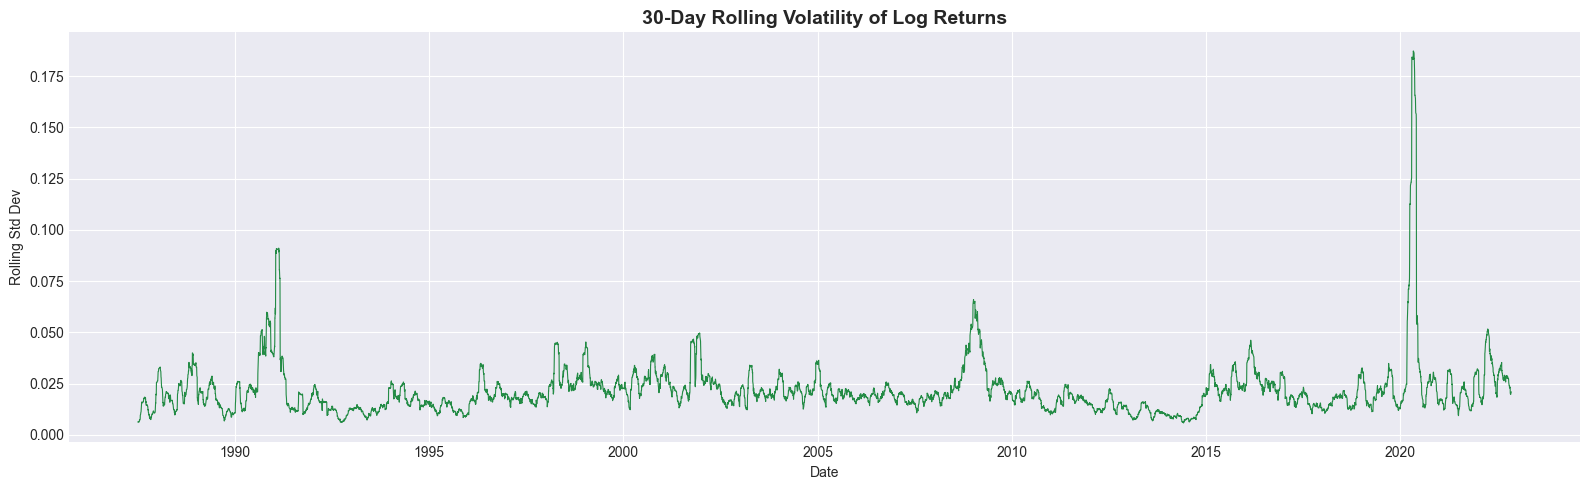

In [9]:
df_returns['RollingVol'] = df_returns['LogReturn'].rolling(window=30).std()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_returns['Date'], df_returns['RollingVol'], linewidth=0.8, color='#238b45')
ax.set_title('30-Day Rolling Volatility of Log Returns', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Std Dev')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../data/rolling_volatility.png', dpi=150)
plt.show()


## 7. Save Processed Data for Task 2

In [10]:
df.to_csv('../data/processed_brent_prices.csv', index=False)
print("Saved processed_brent_prices.csv")


Saved processed_brent_prices.csv
